##Visualize GELECTRA emotion results (titles)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

### Load data

In [2]:
path="/Users/gretawette/Documents/Thesis/04_SentimentAnalysis/outputs/emotion_fulltext_resultsv2.csv"
df = pd.read_csv(path, encoding="utf-8", low_memory=False)
df.columns = df.columns.astype(str).str.replace("\ufeff", "", regex=False).str.strip()

OUTLET_COL = "source" if "source" in df.columns else None
if OUTLET_COL is None:
    for c in df.columns:
        if c.lower() in ("source", "outlet", "datasource"):
            OUTLET_COL = c
            break
if OUTLET_COL is None:
    raise KeyError(f"No outlet column found. Columns: {list(df.columns)}")

EMOTION_COLS = [
    "emotion_anger",
    "emotion_fear",
    "emotion_disgust",
    "emotion_sadness",
    "emotion_joy",
    "emotion_enthusiasm",
    "emotion_pride",
    "emotion_hope",
]
EMOTION_SHORT = [c.replace("emotion_", "") for c in EMOTION_COLS]

for c in EMOTION_COLS:
    if c not in df.columns:
        raise KeyError(f"Missing {c}; got {list(df.columns)}")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["year_month"] = df["Date"].dt.to_period("M").dt.to_timestamp()

print(f"Rows: {len(df):,}")
print(f"Outlets ({OUTLET_COL}): {df[OUTLET_COL].nunique()}")
df[[OUTLET_COL] + EMOTION_COLS[:3]].head()

Rows: 20,431
Outlets (source): 7


,source,emotion_anger,emotion_fear,emotion_disgust
0,Antispiegel,0.776201,0.219879,0.046205
1,Antispiegel,0.687234,0.057936,0.015493
2,Antispiegel,0.922130,0.130471,0.074023
3,Antispiegel,0.945382,0.107717,0.071811
4,Antispiegel,0.912612,0.129464,0.046175


In [3]:
# Emotion colours (aligned with inspiration notebook)
emotion_colors = {
    "anger": "#e66101",
    "fear": "#5e3c99",
    "disgust": "#1b7837",
    "sadness": "#2166ac",
    "joy": "#fdb863",
    "enthusiasm": "#b2abd2",
    "pride": "#d01c8b",
    "hope": "#80cdc1",
}

# Distinct colours for outlets (Tab10 + extras if needed)
outlets_sorted = sorted(df[OUTLET_COL].dropna().unique())
pal = sns.color_palette("tab10", n_colors=max(10, len(outlets_sorted)))
outlet_colors = {o: pal[i % len(pal)] for i, o in enumerate(outlets_sorted)}

<hr style="opacity:0.35">

### Summary statistics

In [4]:
summary_stats = df[EMOTION_COLS].describe().T
summary_stats.index = EMOTION_SHORT
summary_stats = summary_stats.rename(
    columns={
        "count": "N",
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "50%": "Median",
        "max": "Max",
    }
).round(4)
summary_stats

,N,Mean,Std,Min,25%,Median,75%,Max
anger,20431.0,0.7170,0.2095,0.0079,0.5957,0.7690,0.8860,0.9915
fear,20431.0,0.2498,0.1819,0.0041,0.1098,0.2007,0.3491,0.9288
disgust,20431.0,0.0695,0.1093,0.0008,0.0138,0.0325,0.0754,0.9372
sadness,20431.0,0.3265,0.2205,0.0037,0.1554,0.2772,0.4487,0.9425
joy,20431.0,0.0444,0.0519,0.0056,0.0214,0.0303,0.0466,0.9379
enthusiasm,20431.0,0.0783,0.0671,0.0043,0.0375,0.0593,0.0945,0.7984
pride,20431.0,0.1290,0.1200,0.0026,0.0500,0.0912,0.1634,0.9433
hope,20431.0,0.1408,0.1122,0.0053,0.0652,0.1087,0.1782,0.9115


In [5]:
# ── Macro-mean per emotion: mean of per-outlet means ─────────────────────────
per_outlet = df.groupby(OUTLET_COL)[EMOTION_COLS].mean()   # shape: (n_outlets, 8)
macro      = per_outlet.mean().rename(index=lambda c: c.replace("emotion_", ""))

table = pd.DataFrame({
    "Macro-mean": macro.round(4),
    "Min outlet": per_outlet.min().rename(index=lambda c: c.replace("emotion_", "")).round(4),
    "Max outlet": per_outlet.max().rename(index=lambda c: c.replace("emotion_", "")).round(4),
    "Range":      (per_outlet.max() - per_outlet.min())
                  .rename(index=lambda c: c.replace("emotion_", "")).round(4),
})
table.index.name = "Emotion"
display(table.sort_values("Macro-mean", ascending=False))


,Macro-mean,Min outlet,Max outlet,Range
Emotion,,,,
anger,0.7410,0.6647,0.8434,0.1787
sadness,0.3278,0.2817,0.3817,0.1000
fear,0.2543,0.2076,0.3141,0.1066
hope,0.1342,0.1217,0.1606,0.0389
pride,0.1269,0.1059,0.1403,0.0344
enthusiasm,0.0770,0.0683,0.0845,0.0162
disgust,0.0767,0.0451,0.1109,0.0658
joy,0.0445,0.0368,0.0536,0.0168


In [6]:
total_titles = len(df)
outlet_summary = (
    df.groupby(OUTLET_COL, observed=True)
    .size()
    .reset_index(name="N")
    .sort_values("N", ascending=False)
)
outlet_summary["Share (%)"] = (outlet_summary["N"] / total_titles * 100).round(2)
outlet_summary

,source,N,Share (%)
5,Tagesschau,6319,30.93
4,RT_de,4559,22.31
3,Nius,3269,16.00
6,Tichys_Einblick,2756,13.49
1,Compact,1486,7.27
2,Deutschlandkurier,1477,7.23
0,Antispiegel,565,2.77


<hr style="opacity:0.35">

### Visualizations — corpus-wide mean probabilities

Same idea as inspiration: **average softmax score per title**, then **mean across all titles**.

### By outlet: heatmap of mean probabilities

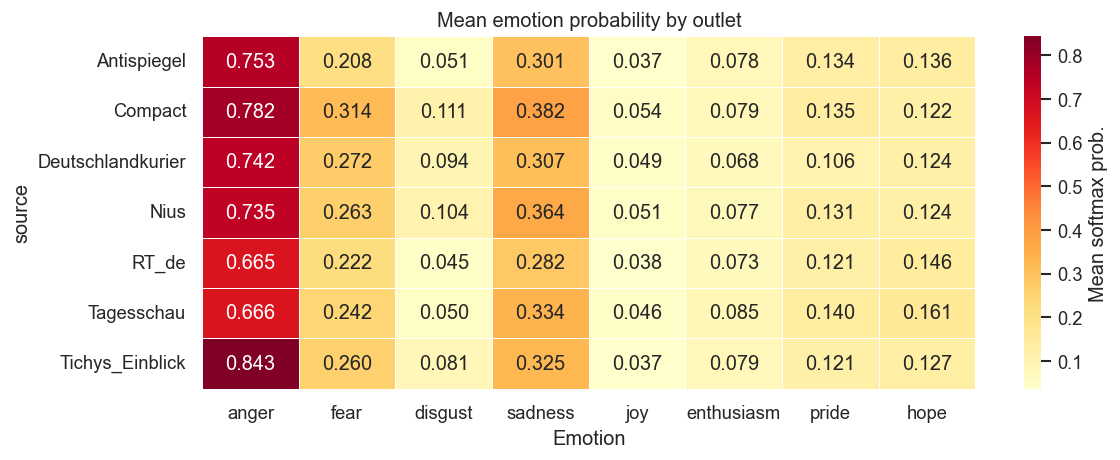

In [7]:
mean_by_outlet = df.groupby(OUTLET_COL, observed=True)[EMOTION_COLS].mean()
mean_by_outlet.columns = EMOTION_SHORT
mean_by_outlet = mean_by_outlet.sort_index()

plt.figure(figsize=(10, max(4, 0.35 * len(mean_by_outlet))))
sns.heatmap(
    mean_by_outlet,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Mean softmax prob."},
)
plt.title("Mean emotion probability by outlet")
plt.ylabel(OUTLET_COL)
plt.xlabel("Emotion")
plt.tight_layout()
plt.show()

In [8]:
# Calculate macro-mean (mean of outlet means) for anger and fear for all outlets except Tagesschau (alternative outlets), 
# and separately for Tagesschau

# Identify alternative outlets (all except Tagesschau)
alternative_outlets = mean_by_outlet.index[mean_by_outlet.index != "Tagesschau"]

# Calculate macro-mean for anger for alternative outlets
anger_macro_mean_alt = mean_by_outlet.loc[alternative_outlets, "anger"].mean()

# Calculate macro-mean for fear for alternative outlets
fear_macro_mean_alt = mean_by_outlet.loc[alternative_outlets, "fear"].mean()

# Get mean anger and fear for Tagesschau
anger_mean_tagesschau = mean_by_outlet.loc["Tagesschau", "anger"]
fear_mean_tagesschau = mean_by_outlet.loc["Tagesschau", "fear"]

print(f"Macro-mean anger (alternative outlets): {anger_macro_mean_alt:.4f}")
print(f"Tagesschau anger mean: {anger_mean_tagesschau:.4f}")
print(f"Macro-mean fear (alternative outlets): {fear_macro_mean_alt:.4f}")
print(f"Tagesschau fear mean: {fear_mean_tagesschau:.4f}")

Macro-mean anger (alternative outlets): 0.7535
Tagesschau anger mean: 0.6656
Macro-mean fear (alternative outlets): 0.2563
Tagesschau fear mean: 0.2424
